In [1]:
# Importing permitted libraries only
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Make sure data.csv is in the same directory
df = pd.read_csv('data.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1500, 201)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X192,X193,X194,X195,X196,X197,X198,X199,X200,y
0,-0.105716,-1.056372,0.472175,-0.624175,-1.337268,0.109321,0.293656,0.635470,-0.871020,0.194277,...,0.101041,0.708435,1.343249,-1.202234,-1.333481,-0.888842,0.134859,0.355681,-1.193989,180.621931
1,1.255322,0.125270,0.450023,2.003561,0.277094,0.450579,0.462558,-0.316563,0.052639,0.188200,...,-0.638715,0.407518,1.452270,-1.047522,0.697560,0.335719,-2.483643,0.396654,-1.337587,8.336719
2,0.655216,0.825484,-0.890328,0.105923,-0.627933,1.788487,-0.338370,-0.601686,-0.837622,-0.085283,...,0.108930,1.120339,-0.557336,0.542774,-2.099880,0.766930,-0.640871,0.607291,0.593155,178.514922
3,-0.862742,-0.297754,0.316790,-2.747953,-0.468321,1.168713,-0.639897,0.602207,-0.390683,-0.279624,...,1.174023,-0.597059,-0.768229,-1.508851,-1.563351,0.824011,1.152560,0.288155,0.428682,233.401328
4,-0.492418,0.832162,-0.704394,-0.502445,0.734592,-0.435019,-0.017912,-1.992973,-0.129440,1.429077,...,1.123942,2.143922,2.052964,0.224794,1.871673,-0.728549,-1.876174,-1.169126,1.209643,-98.768226


In [4]:
# 2. Separate features (X) from labels (y)
# Assuming 'target' is the column name for your label. Replace 'target' with your actual column name.
X = df.drop(columns=['y']) 
y = df['y']

# Splitting the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing features is highly recommended for regularization models like Lasso/Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 3. Use Lasso Regression to select the best features
# Adjust alpha to control the strength of regularization and number of features selected.
# Higher alpha values eliminate more features.
lasso = Lasso(alpha=0.1, random_state=42) 
lasso.fit(X_train_scaled, y_train)

# Filter features where coefficients are not zero
importance = np.abs(lasso.coef_)
selected_features_indices = np.where(importance > 0)[0]

# Subset your datasets to only keep selected features
X_train_selected = X_train_scaled[:, selected_features_indices]
X_test_selected = X_test_scaled[:, selected_features_indices]

print(f"Number of features selected: {len(selected_features_indices)}")
print("Note: The lab requires a range between 10 and 170 features.")

Number of features selected: 10
Note: The lab requires a range between 10 and 170 features.


In [6]:
# 4. Use Ridge Regression to model the dataset
# alpha controls the penalty strength for Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_selected, y_train)

# Make predictions on the testing set
y_pred = ridge.predict(X_test_selected)

# 5. Calculate the RMSE and R2 Score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Root Mean Squared Error (RMSE): 0.1941
R2 Score: 1.0000


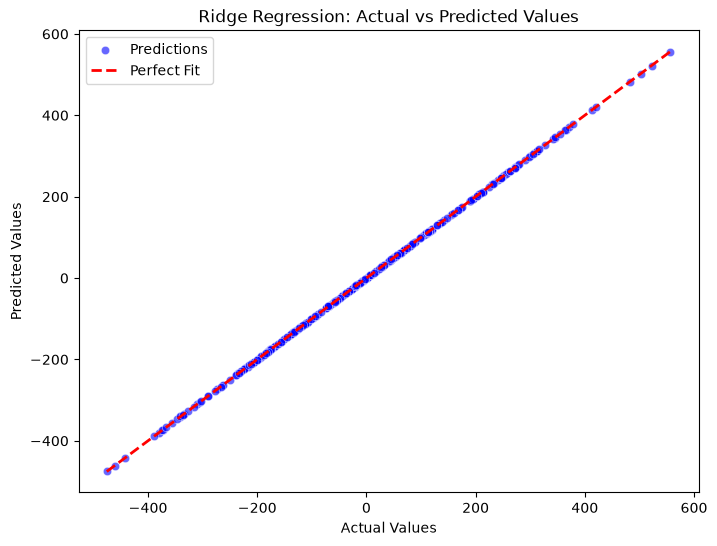

In [7]:
# 6. Plotting the line of best fit (Actual vs Predicted)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Ridge Regression: Actual vs Predicted Values')
plt.legend()
plt.show()